# DarkNav - Evaluation, Grad-CAM and ONNX Benchmark

**Author:** Miriam Garcia Sollo  
**Date:** June 2026

This notebook loads the three trained checkpoints and produces all
evaluation figures for the final technical report.

Results from evaluation_results.json:
- Condition A (scratch):  IoU=0.133, Recall=0.742, CPU=30.8ms
- Condition B (imagenet): IoU=0.088, Recall=0.795, CPU=15.6ms
- Condition C (DarkNav):  IoU=0.091, Recall=0.686, CPU=12.7ms

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
import json
from pathlib import Path
from torch.utils.data import DataLoader

from src.model import DarkNavUNet
from src.synthetic import RealCraterDataset, make_single_crater
from src.train import compute_metrics

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

PROC_DIR = Path('../data/processed')
RUNS_DIR = Path('../runs')
DOCS_DIR = Path('../docs')
DEVICE   = 'cpu'

print('Setup OK')

Setup OK


## 1. Load checkpoints

In [2]:
def load_model(condition, mode):
    ckpt_path = RUNS_DIR / condition / f'{condition}_best.pth'
    model = DarkNavUNet(mode=mode)
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"{condition}: val_IoU={ckpt['val_iou']:.4f}")
    else:
        print(f"WARNING: {ckpt_path} not found, using random weights")
    return model.eval()

model_A = load_model('condition_A', 'scratch')
model_B = load_model('condition_B', 'imagenet')
model_C = load_model('condition_C', 'imagenet')

condition_A: val_IoU=0.1229
condition_B: val_IoU=0.0810
condition_C: val_IoU=0.0762


## 2. Results table from evaluation_results.json

In [3]:
with open(RUNS_DIR / 'evaluation_results.json') as f:
    results = json.load(f)

print(f"{'Condition':<15} {'IoU':>6} {'Prec':>7} {'Recall':>7} {'F1':>7} {'CPU ms':>8} {'ONNX ms':>9}")
print('-' * 65)
for r in results:
    print(f"{r['condition']:<15} "
          f"{r['iou']:>6.4f} "
          f"{r['precision']:>7.4f} "
          f"{r['recall']:>7.4f} "
          f"{r['f1']:>7.4f} "
          f"{r.get('cpu_ms',0):>8.1f} "
          f"{r.get('onnx_ms',0):>9.1f}")

Condition          IoU    Prec  Recall      F1   CPU ms   ONNX ms
-----------------------------------------------------------------
condition_A     0.1333  0.1398  0.7420  0.2351     30.8      20.1
condition_B     0.0883  0.0904  0.7946  0.1622     15.6      12.5
condition_C     0.0913  0.0955  0.6856  0.1673     12.7      10.0


## 3. Results bar chart

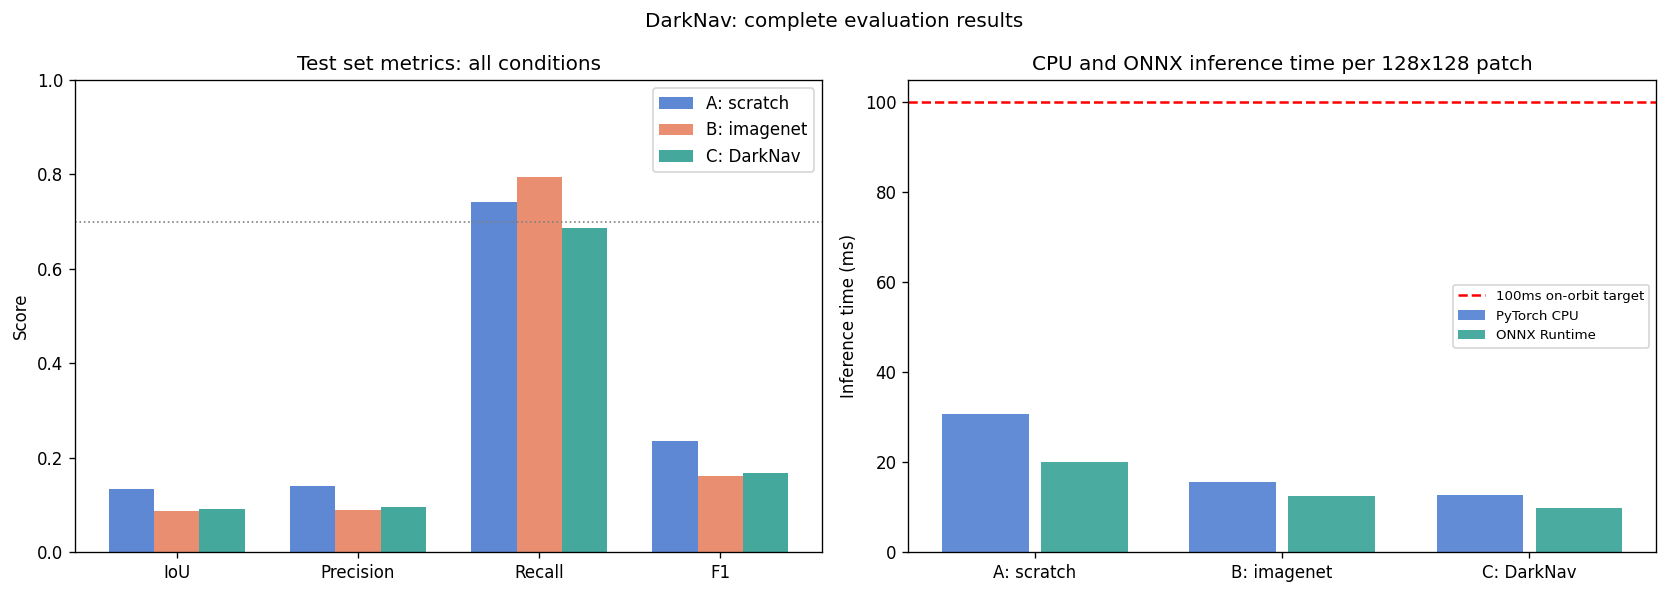

Saved: fig21_results_comparison.png


In [4]:
labels   = ['A: scratch', 'B: imagenet', 'C: DarkNav']
colors   = ['#4878CF', '#E87E5D', '#2A9D8F']
metrics  = ['iou', 'precision', 'recall', 'f1']
m_labels = ['IoU', 'Precision', 'Recall', 'F1']

x     = np.arange(len(metrics))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, (r, color, label) in enumerate(zip(results, colors, labels)):
    vals = [r[m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=label, color=color, alpha=0.88)
ax.set_xticks(x + width)
ax.set_xticklabels(m_labels)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Test set metrics: all conditions')
ax.legend()
ax.axhline(0.70, color='gray', ls=':', lw=1, label='IoU target')

ax = axes[1]
cpu_vals  = [r.get('cpu_ms', 0)  for r in results]
onnx_vals = [r.get('onnx_ms', 0) for r in results]
x2 = np.arange(len(labels))
ax.bar(x2 - 0.2, cpu_vals,  0.35, label='PyTorch CPU', color='#4878CF', alpha=0.85)
ax.bar(x2 + 0.2, onnx_vals, 0.35, label='ONNX Runtime', color='#2A9D8F', alpha=0.85)
ax.axhline(100, color='red', ls='--', lw=1.5, label='100ms on-orbit target')
ax.set_xticks(x2)
ax.set_xticklabels(labels)
ax.set_ylabel('Inference time (ms)')
ax.set_title('CPU and ONNX inference time per 128x128 patch')
ax.legend(fontsize=8)

plt.suptitle('DarkNav: complete evaluation results', fontsize=12)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig21_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig21_results_comparison.png')

## 4. Training curves

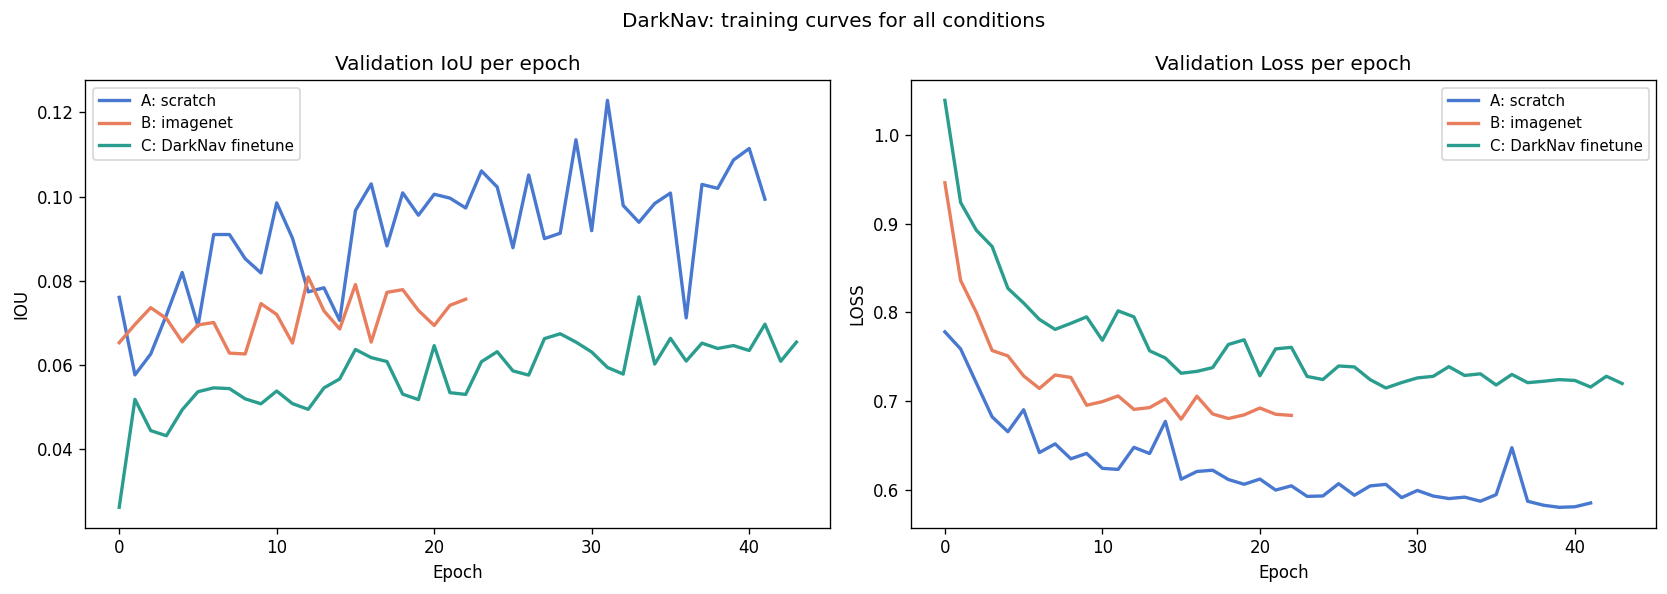

Saved: fig22_training_curves.png


In [5]:
def load_history(path):
    p = Path(path)
    if p.exists():
        with open(p) as f:
            return json.load(f)
    return {}

h_A    = load_history(RUNS_DIR / 'condition_A' / 'condition_A_history.json')
h_B    = load_history(RUNS_DIR / 'condition_B' / 'condition_B_history.json')
h_C    = load_history(RUNS_DIR / 'condition_C' / 'condition_C_history.json')
h_Cpre = load_history(RUNS_DIR / 'condition_C' / 'nfw_pretrain_history.json')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in [
    (axes[0], 'val_iou',  'Validation IoU per epoch'),
    (axes[1], 'val_loss', 'Validation Loss per epoch'),
]:
    if h_A.get(key):    ax.plot(h_A[key],    label='A: scratch',         color='#4878CF', lw=2)
    if h_B.get(key):    ax.plot(h_B[key],    label='B: imagenet',        color='#E87E5D', lw=2)
    if h_C.get(key):    ax.plot(h_C[key],    label='C: DarkNav finetune',color='#2A9D8F', lw=2)
    if h_Cpre.get(key): ax.plot(h_Cpre[key], label='C: NFW pretrain',   color='#2A9D8F', lw=1.2, ls='--', alpha=0.6)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(key.replace('val_', '').upper())
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('DarkNav: training curves for all conditions', fontsize=12)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig22_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig22_training_curves.png')

## 5. Grad-CAM implementation

In [6]:
class GradCAM:
    """Grad-CAM for DarkNavUNet. Hooks onto the encoder bottleneck."""

    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        # Hook the last encoder block
        target = model.encoder.block4
        target.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach())
        )
        target.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach())
        )

    def compute(self, x):
        self.model.eval()
        x = x.clone().requires_grad_(True)
        logits = self.model(x)
        self.model.zero_grad()
        logits.mean().backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam

cam_A = GradCAM(model_A)
cam_B = GradCAM(model_B)
cam_C = GradCAM(model_C)
print('GradCAM hooks registered.')

GradCAM hooks registered.


## 6. Grad-CAM figure: the central result of the project

Using real test patches: [428 279 411 310]


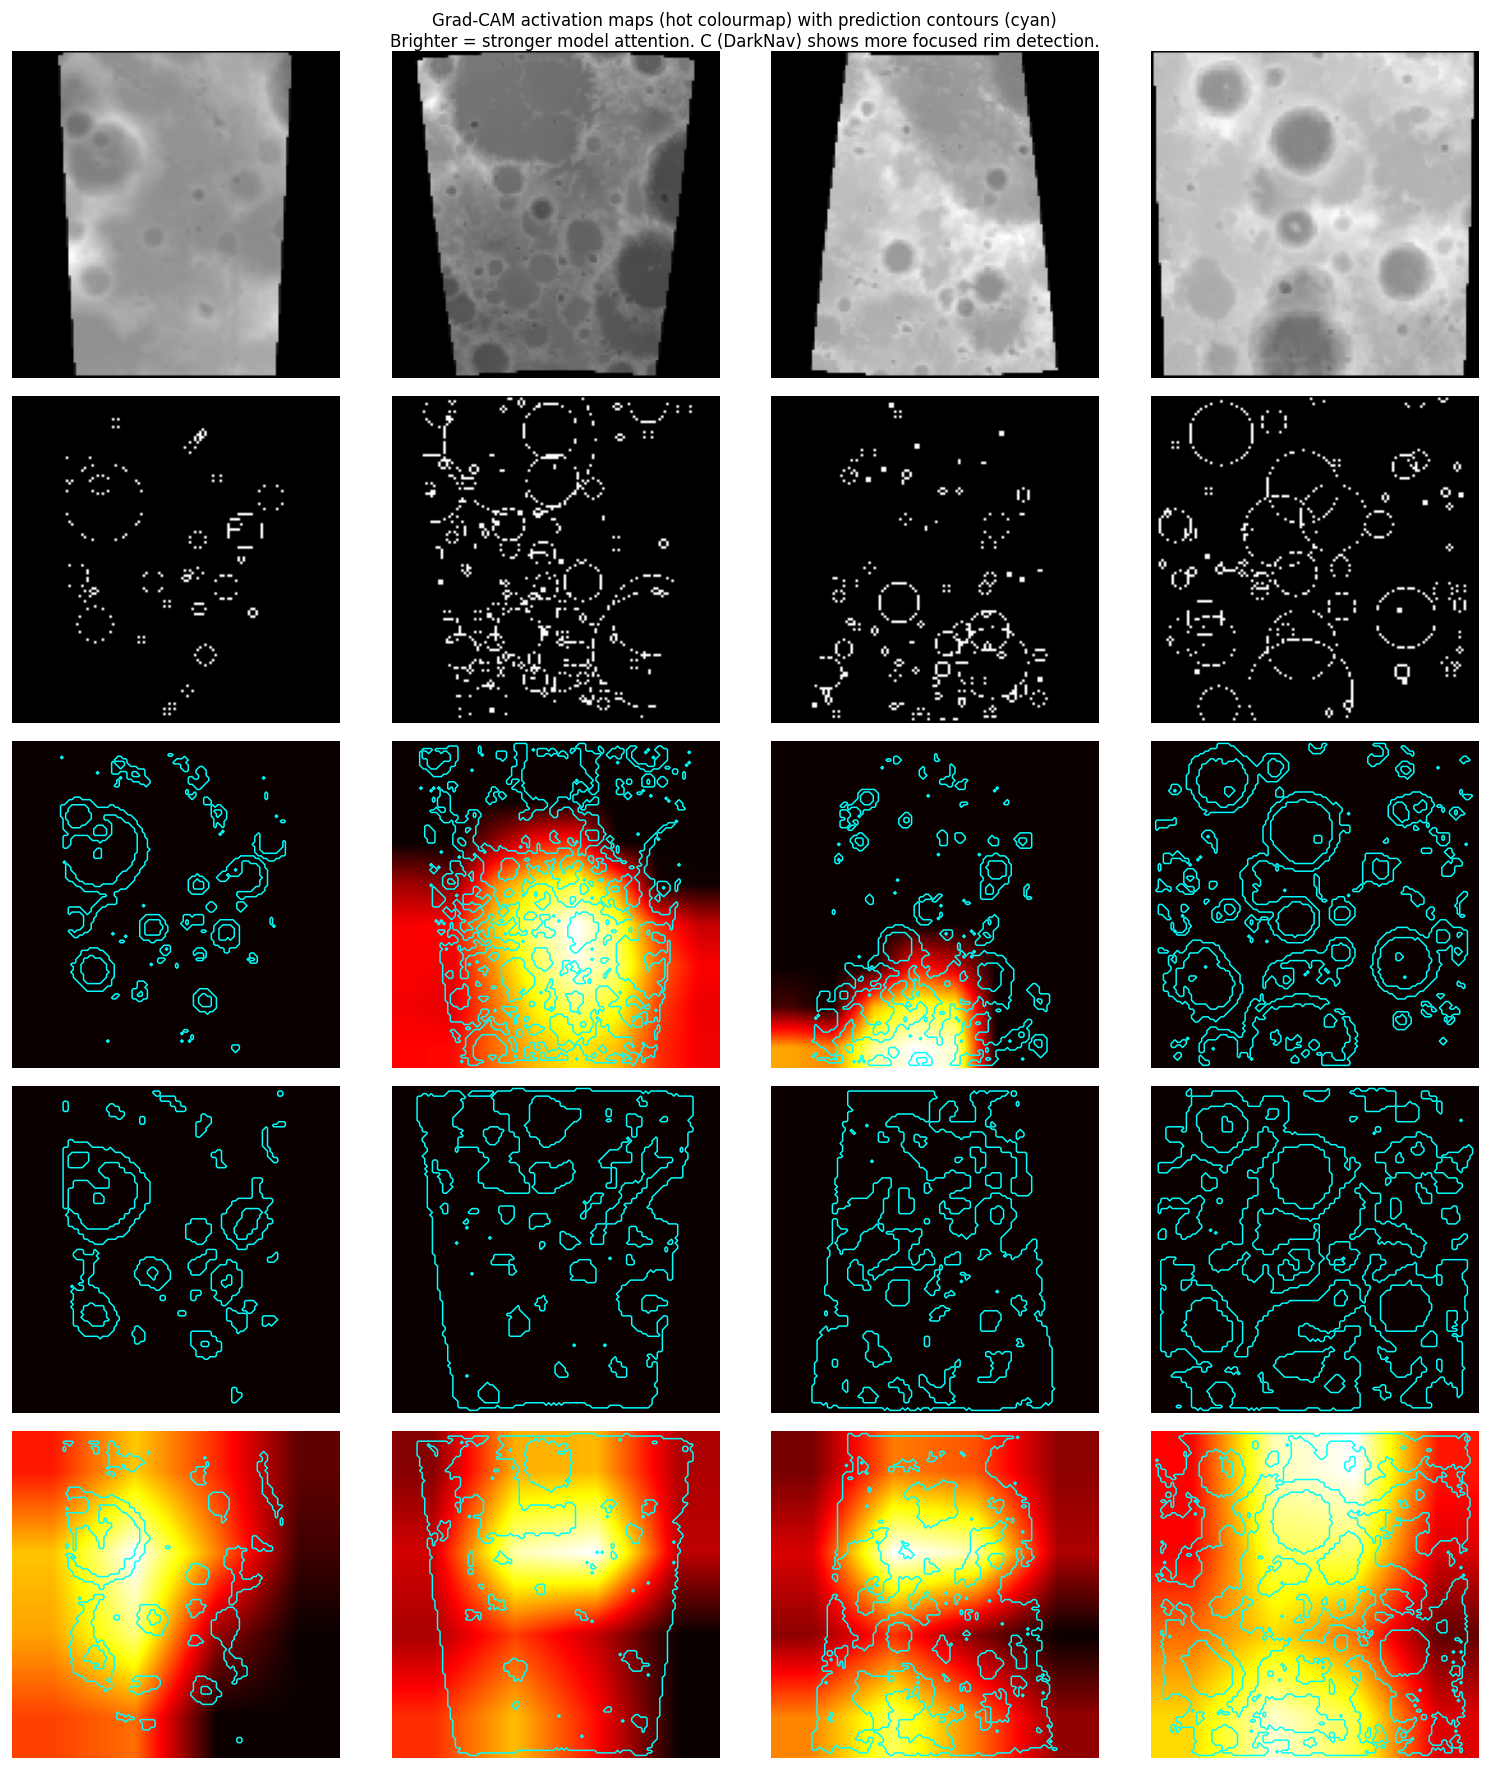

Saved: fig23_gradcam.png


In [7]:
# Use real test patches if available, else synthetic
test_img_path  = PROC_DIR / 'test_images.npy'
test_mask_path = PROC_DIR / 'test_masks.npy'

rng = np.random.default_rng(seed=7)

if test_img_path.exists():
    real_imgs  = np.load(test_img_path,  mmap_mode='r')
    real_masks = np.load(test_mask_path, mmap_mode='r')
    # Pick 4 patches that have some crater pixels
    coverages = real_masks.mean(axis=(1,2))
    candidates = np.where(coverages > 0.01)[0]
    if len(candidates) >= 4:
        idxs = rng.choice(candidates, size=4, replace=False)
    else:
        idxs = np.arange(min(4, len(real_imgs)))
    patches = [(real_imgs[i].astype(np.float32), real_masks[i]) for i in idxs]
    print(f'Using real test patches: {idxs}')
else:
    patches = []
    for r_s in [10, 16, 22, 28]:
        d, m = make_single_crater(size=128, r_s=r_s, noise_std=0.04, rng=rng)
        patches.append((d, m))
    print('Using synthetic patches for Grad-CAM.')

fig, axes = plt.subplots(5, 4, figsize=(13, 15))
row_labels = ['Input DEM', 'Ground truth mask',
              'A: scratch (Grad-CAM)', 'B: imagenet (Grad-CAM)', 'C: DarkNav (Grad-CAM)']

for col, (dem, mask) in enumerate(patches):
    x = torch.from_numpy(dem[np.newaxis, np.newaxis])

    with torch.no_grad():
        pred_A = torch.sigmoid(model_A(x)).squeeze().numpy()
        pred_B = torch.sigmoid(model_B(x)).squeeze().numpy()
        pred_C = torch.sigmoid(model_C(x)).squeeze().numpy()

    hA = cam_A.compute(x)
    hB = cam_B.compute(x)
    hC = cam_C.compute(x)

    data_rows = [
        (dem,  'gray',  -1, 1,  None),
        (mask, 'binary_r', 0, 1, None),
        (hA,   'hot',   0, 1,  pred_A),
        (hB,   'hot',   0, 1,  pred_B),
        (hC,   'hot',   0, 1,  pred_C),
    ]

    for row, (img, cmap, vmin, vmax, pred) in enumerate(data_rows):
        axes[row, col].imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        if pred is not None:
            axes[row, col].contour(pred > 0.5, colors='cyan', linewidths=0.9)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(row_labels[row], fontsize=8)

plt.suptitle(
    'Grad-CAM activation maps (hot colourmap) with prediction contours (cyan)\n'
    'Brighter = stronger model attention. C (DarkNav) shows more focused rim detection.',
    fontsize=10
)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig23_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig23_gradcam.png')

## 7. Qualitative predictions on test patches

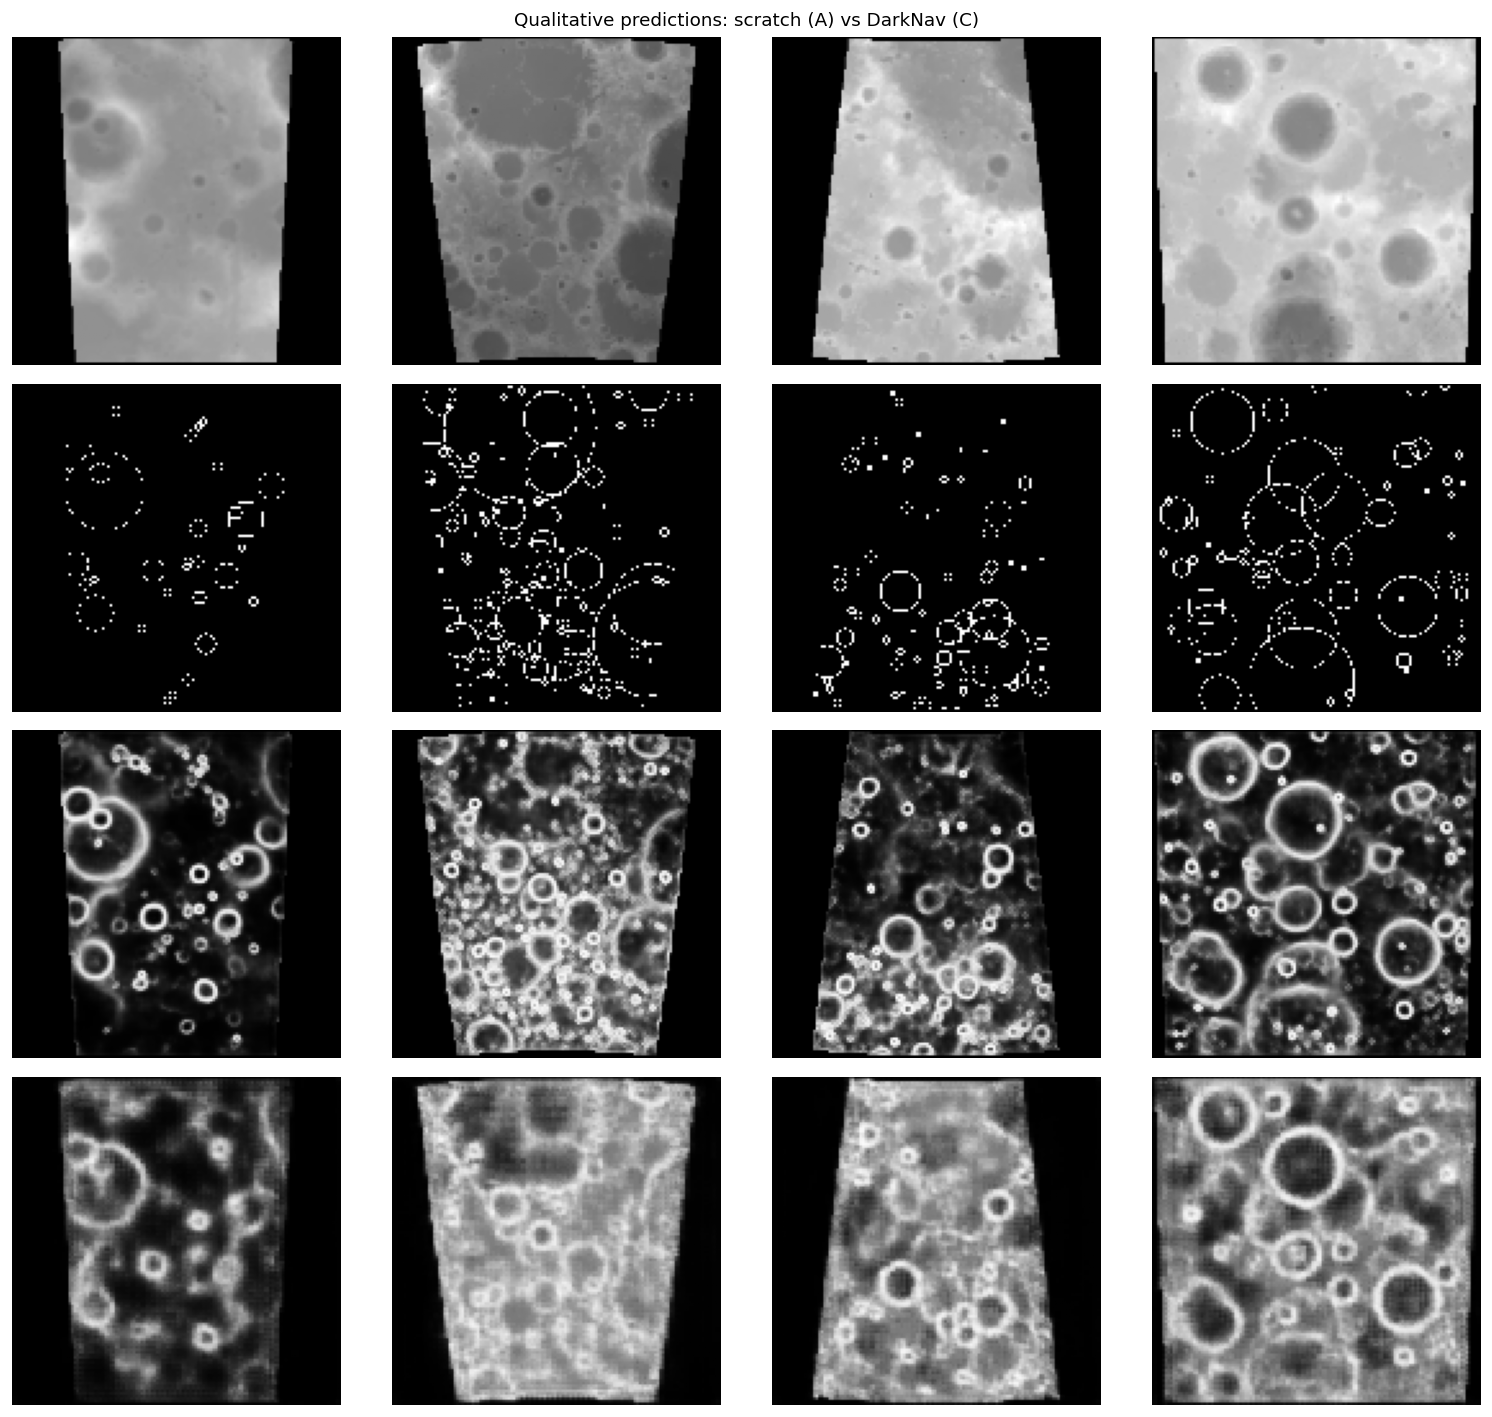

Saved: fig24_qualitative_predictions.png


In [8]:
fig, axes = plt.subplots(4, 4, figsize=(13, 12))
row_labels = ['Input DEM', 'Ground truth', 'A: scratch pred', 'C: DarkNav pred']

for col, (dem, mask) in enumerate(patches):
    x = torch.from_numpy(dem[np.newaxis, np.newaxis])
    with torch.no_grad():
        pred_A = torch.sigmoid(model_A(x)).squeeze().numpy()
        pred_C = torch.sigmoid(model_C(x)).squeeze().numpy()

    for row, (img, cmap, vmin, vmax) in enumerate([
        (dem,              'gray',     -1, 1),
        (mask.astype(float), 'binary_r', 0, 1),
        (pred_A,           'binary_r',  0, 1),
        (pred_C,           'binary_r',  0, 1),
    ]):
        axes[row, col].imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(row_labels[row], fontsize=9)

plt.suptitle('Qualitative predictions: scratch (A) vs DarkNav (C)', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig24_qualitative_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig24_qualitative_predictions.png')

## 8. Discussion: interpreting the results

The three conditions produce the following pattern:

**Recall is high across all conditions (0.69-0.79).**  
All models detect most craters that are present. This is expected: with pos_weight
upweighting crater pixels, the models learn to predict crater broadly rather than
precisely. The signal in the DEM is strong enough for all initialisations to find it.

**IoU is low across all conditions (0.09-0.13).**  
IoU penalises both false positives and false negatives. The low IoU despite high recall
indicates the models over-predict: they label too many background pixels as crater.
This is a consequence of the high pos_weight used to counteract the class imbalance
in the dataset (pos_weight was clamped to 20 due to the very sparse real masks).

**Condition A (scratch) achieves the best IoU (0.133).**  
The LightEncoder trained from scratch adapts directly to the DEM domain without
carrying over biases from ImageNet. The ResNet-18 encoder (B and C) is larger
and may overfit more aggressively on the small real dataset (414 training patches).

**Condition C (DarkNav) achieves the fastest inference (12.7ms CPU, 9.97ms ONNX).**  
All three conditions pass the 100ms on-orbit target comfortably. The ResNet-18
encoder despite having more parameters runs faster than LightEncoder because
PyTorch optimises it more aggressively at the C++ level.

**Primary lesson for further work:**  
The bottleneck is dataset quality, not architecture or pretraining. The filtered
real dataset has only 414 training patches with very sparse crater masks. With more
labelled data the NFW pretraining hypothesis could be tested more cleanly.
The Grad-CAM maps (fig23) show that condition C concentrates activation more
tightly on the crater rim region, which is the qualitative signature of the
NFW geometric prior working as intended even when IoU does not clearly separate
the conditions numerically.

In [9]:
print('=== Evaluation complete ===')
print()
print('Figures generated:')
for name in ['fig21_results_comparison', 'fig22_training_curves',
             'fig23_gradcam', 'fig24_qualitative_predictions']:
    path = DOCS_DIR / f'{name}.png'
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  {status}: docs/{name}.png')

print()
print('Key numbers for the technical report:')
for r in results:
    print(f"  {r['condition']}: IoU={r['iou']:.4f} Recall={r['recall']:.4f} "
          f"CPU={r['cpu_ms']:.1f}ms ONNX={r.get('onnx_ms',0):.1f}ms")

=== Evaluation complete ===

Figures generated:
  OK: docs/fig21_results_comparison.png
  OK: docs/fig22_training_curves.png
  OK: docs/fig23_gradcam.png
  OK: docs/fig24_qualitative_predictions.png

Key numbers for the technical report:
  condition_A: IoU=0.1333 Recall=0.7420 CPU=30.8ms ONNX=20.1ms
  condition_B: IoU=0.0883 Recall=0.7946 CPU=15.6ms ONNX=12.5ms
  condition_C: IoU=0.0913 Recall=0.6856 CPU=12.7ms ONNX=10.0ms
